In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. The "Cinema Survey" Data
cinema_data = {
    'Viewer_Age': [45, 45, 18, 34, 29, 55, 21, 38, 40],
    'Show_Time': ['Evening', 'Matinee', 'Evening', 'Late Night', 'Evening', 'Late Night', 'Late Night', 'Matinee', 'Evening'],
    'First_Time': [True, False, True, True, False, False, True, False, True],
    'Enjoyment': [5, 4, 5, 2, 4, 3, 1, 5, 4]
}

df = pd.DataFrame(cinema_data)
df

,Viewer_Age,Show_Time,First_Time,Enjoyment
0,45,Evening,True,5
1,45,Matinee,False,4
2,18,Evening,True,5
3,34,Late Night,True,2
4,29,Evening,False,4
5,55,Late Night,False,3
6,21,Late Night,True,1
7,38,Matinee,False,5
8,40,Evening,True,4


# Resultados:

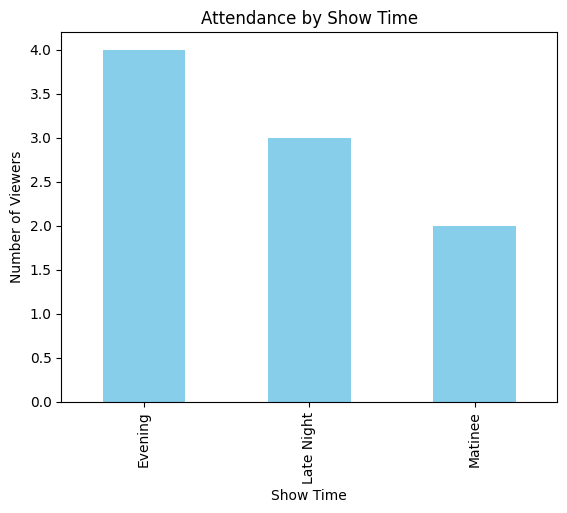

In [3]:
# 2. Count how many people attended each time slot
time_counts = df['Show_Time'].value_counts()
time_counts.plot(kind='bar', color='skyblue')
plt.title('Attendance by Show Time')
plt.ylabel('Number of Viewers')
plt.xlabel('Show Time')
plt.show()

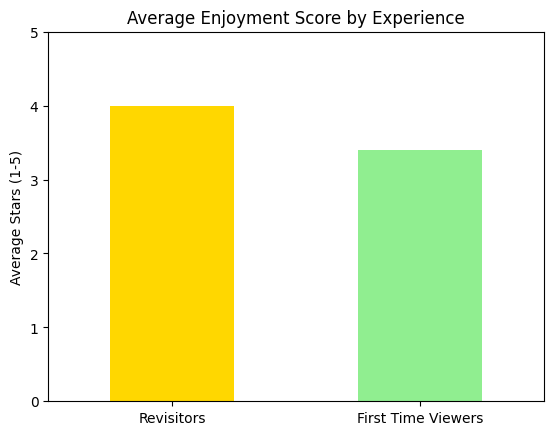

In [7]:
# 3. Calculate and Plot
avg_enjoyment = df.groupby('First_Time')['Enjoyment'].mean()
avg_enjoyment.index = ['Revisitors', 'First Time Viewers']
avg_enjoyment.plot(kind='bar', color=['gold', 'lightgreen'])
plt.ylabel('Average Stars (1-5)')
plt.title('Average Enjoyment Score by Experience')
plt.xticks(rotation=0) # Keeps the names horizontal
plt.ylim(0, 5) 
plt.show()

In [4]:
import ipywidgets as widgets
from IPython.display import display

In [5]:
# 4. Create two separate dataframes based on time
evening_fans = df[df['Show_Time'] == 'Evening']
matinee_fans = df[df['Show_Time'] == 'Matinee']

# Calculate the averages
print(f"Evening Average Rating: {evening_fans['Enjoyment'].mean():.2f} stars")
print(f"Matinee Average Rating: {matinee_fans['Enjoyment'].mean():.2f} stars")

Evening Average Rating: 4.67 stars
Matinee Average Rating: 4.50 stars


In [6]:
# 5. Interactive Slider to view data from different samples
def show_rating_by_age(selected_age):
    # Filter for the specific age selected on the slider
    age_df = df[df['Viewer_Age'] == selected_age]
    
    if not age_df.empty:
        # Calculate the average for that specific age
        avg_rating = age_df['Enjoyment'].mean()
        
        # Create a simple bar to show the rating
        plt.figure(figsize=(5, 4))
        plt.bar(str(selected_age), avg_rating, color='skyblue')
        plt.ylim(0, 5)
        plt.ylabel("Average Rating")
        plt.title(f"Average Rating for Age {selected_age}: {avg_rating} Stars")
        plt.show()
    else:
        print(f"No data for age {selected_age}. Keep sliding!")

# 3. Create the slider and link it
# 'selected_age' in the interact function matches the argument in our show_rating_by_age function
widgets.interact(show_rating_by_age, selected_age=widgets.IntSlider(
    value=22, 
    min=18, 
    max=55, 
    step=1, 
    description='Age:'
));

interactive(children=(IntSlider(value=22, description='Age:', max=55, min=18), Output()), _dom_classes=('widge…